# Assignment 2: Stock Market Analysis Agent

This notebook walks through the full LangGraph agent step-by-step.

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '.')  # Ensure the local 'agent' package is discoverable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Import real compiled graph constructor and individual nodes
from agent.graph import build_graph
from agent.nodes import fetch_data, calculate_indicators, generate_recommendation, format_report
from agent.state import StockAgentState

print("Setup completed successfully. All live modules imported!")

Setup completed successfully. All live modules imported!


In [2]:
# State Container Initialization
TICKER = 'TSLA'  # Should work when try 'NVDA', 'MSFT', 'TSLA', etc.

state: StockAgentState = {
    'ticker':         TICKER.upper().strip(),
    'raw_data':       None,
    'indicators':     None,
    'recommendation': None,
    'report':         None,
    'error':          None,
}

print(f"Workflow initiated for ticker: {state['ticker']}")

# Execute Live Data Fetching Node
state.update(fetch_data(state))

if state.get('error'):
    print(f"Error encountered during data extraction: {state['error']}")
else:
    print(f"Step 1 Complete: Extracted {len(state['raw_data'])} live trading rows via yfinance.")
    display(state['raw_data'].tail(3))

# Generate Math Indicators 
if not state.get('error'):
    state.update(calculate_indicators(state))
    print("\nStep 2 Complete: Appended indicators to data profile.")
    # Extract calculated metrics from dictionary dictionary payload
    ind = state['indicators']
    print(f"  Current Price: ${ind['current_price']:.2f}")
    print(f"  SMA-10 Metric: ${ind['sma_10']:.2f}")
    print(f"  SMA-20 Metric: ${ind['sma_20']:.2f}")
    print(f"  RSI-14 Weight: {ind['rsi_14']:.2f}")

# Run Recommendation Logic Matrix 
if not state.get('error'):
    state.update(generate_recommendation(state))
    print("\nStep 3 Complete: Recommendation engine evaluated.")
    print(f"  Action Verdict: {state['recommendation']['action']}")
    print(f"  Confidence Score: {state['recommendation']['confidence']}")

# Run Professional Report Printer
state.update(format_report(state))
print("\nStep 4 Complete: Rendering generated report string...\n")
# print(state['report'])

Workflow initiated for ticker: TSLA
Step 1 Complete: Extracted 60 live trading rows via yfinance.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-20 00:00:00-04:00,407.600006,417.459991,406.390015,417.260010,45294700,0.0,0.0
2026-05-21 00:00:00-04:00,422.179993,426.950012,412.899994,417.850006,42636900,0.0,0.0
2026-05-22 00:00:00-04:00,422.670013,431.510010,420.510010,426.010010,45944100,0.0,0.0



Step 2 Complete: Appended indicators to data profile.
  Current Price: $426.01
  SMA-10 Metric: $426.45
  SMA-20 Metric: $409.26
  RSI-14 Weight: 61.54

Step 3 Complete: Recommendation engine evaluated.
  Action Verdict: BUY
  Confidence Score: Moderate

Step 4 Complete: Rendering generated report string...



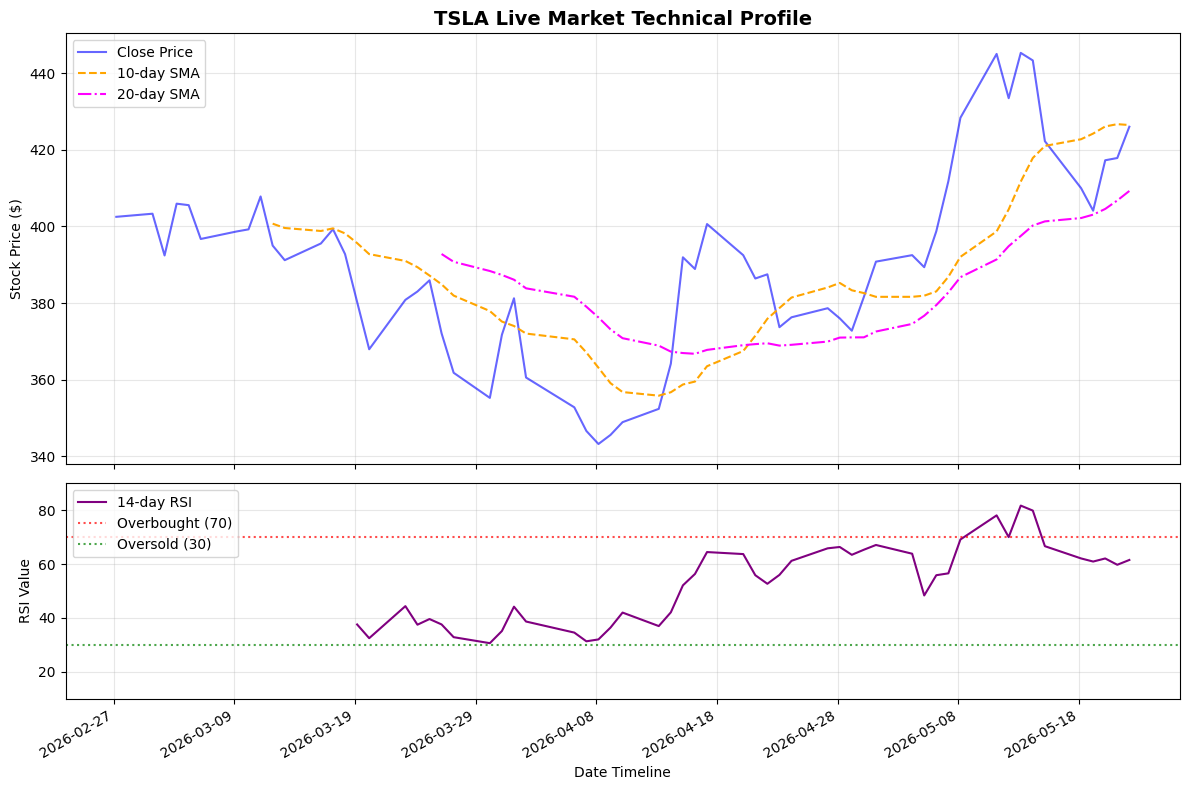

In [3]:
def plot_live_analysis(state: StockAgentState):
    """Plots historical close tracking against calculated SMA bands and RSI momentum."""
    if state.get('error') or state['indicators'] is None:
        print("Cannot plot graph: State contains errors or missing data arrays.")
        return

    # Extract calculated indicators package and target df
    ind = state['indicators']
    df = ind['data_df']
    ticker = state['ticker']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})

    # Top Chart: Price and Moving Average Crossovers
    ax1.plot(df.index, df['Close'], label='Close Price', color='blue', alpha=0.6)
    ax1.plot(df.index, df['SMA_10'], label='10-day SMA', color='orange', linestyle='--')
    ax1.plot(df.index, df['SMA_20'], label='20-day SMA', color='magenta', linestyle='-.')
    ax1.set_title(f"{ticker} Live Market Technical Profile", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Stock Price ($)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Bottom Chart: RSI Momentum
    ax2.plot(df.index, df['RSI_14'], label='14-day RSI', color='purple')
    ax2.axhline(70, color='red', linestyle=':', alpha=0.7, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle=':', alpha=0.7, label='Oversold (30)')
    ax2.set_ylabel("RSI Value")
    ax2.set_xlabel("Date Timeline")
    ax2.set_ylim(10, 90)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # Format Date output string styling across axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

# Visualize the stock run from Cell 2
plot_live_analysis(state)

In [4]:
def run_analysis(ticker: str) -> dict:
    """
    Compiles and invokes the full LangGraph infrastructure end-to-end 
    using actual, unfiltered Yahoo Finance market records.
    """
    # Build compiled graph schema from agent/graph.py
    agent_graph = build_graph()

    # Instantiate the structural state blueprint
    initial_state = {
        'ticker':         ticker.upper().strip(),
        'raw_data':       None,
        'indicators':     None,
        'recommendation': None,
        'report':         None,
        'error':          None,
    }

    # Pass configuration map parameters to execution context
    final_output_state = agent_graph.invoke(initial_state)
    return final_output_state

print("End-to-End Live Graph runner pipeline ready.")

End-to-End Live Graph runner pipeline ready.
